# Creating a logistic regression model to predict the Fraud

## Importing the Relevant Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading the preprocessed data 

In [2]:
data_preprocessed = pd.read_csv('txn_preprocessed.csv')

In [3]:
data_preprocessed.head()

,time_diff_sec,availableMoney,transactionAmount,currentBalance,cardPresent,expirationDateKeyInMatch,cvv_match,0,1,2,...,9,10,11,12,13,14,15,16,17,isFraud
0,5063902.0,5000.0,74.51,0.0,1,0,0,1,0,0,...,0,1,0,0,0,0,1,1,0,0
1,2434365.0,5000.0,7.47,0.0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,1,0,0
2,2739371.0,5000.0,7.47,0.0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,1,0,0
3,2229581.0,5000.0,30.76,0.0,1,0,0,1,0,0,...,0,1,0,0,0,0,1,1,0,0
4,2759168.0,5000.0,57.28,0.0,1,0,0,1,0,0,...,0,1,0,0,0,0,1,1,0,0


In [4]:
data_preprocessed[['time_diff_sec','availableMoney','transactionAmount','currentBalance','isFraud']].describe()


,time_diff_sec,availableMoney,transactionAmount,currentBalance,isFraud
count,7.813630e+05,781363.000000,781363.000000,781363.000000,781363.000000
mean,1.832822e+05,6225.779060,137.016299,4537.590846,0.015798
std,5.356827e+05,8861.522276,147.736755,6467.957401,0.124694
min,0.000000e+00,-1005.630000,0.000000,0.000000,0.000000
25%,6.593000e+03,1073.295000,33.680000,714.420000,0.000000
50%,3.363700e+04,3165.820000,87.920000,2486.280000,0.000000
75%,1.414870e+05,7489.940000,191.540000,5334.665000,0.000000
max,2.835306e+07,50000.000000,2011.540000,47498.810000,1.000000


In [5]:
data_preprocessed.isna().any()

time_diff_sec               False
availableMoney              False
transactionAmount           False
currentBalance              False
cardPresent                 False
expirationDateKeyInMatch    False
cvv_match                   False
0                           False
1                           False
2                           False
3                           False
4                           False
5                           False
6                           False
7                           False
8                           False
9                           False
10                          False
11                          False
12                          False
13                          False
14                          False
15                          False
16                          False
17                          False
isFraud                     False
dtype: bool

In [6]:
target=data_preprocessed['isFraud']

### percentage of chances that fraud not happened

In [7]:
fraud = (target.sum()/target.shape[0])*100
print(fraud,'%')

1.5798034972221617 %


### % of chances that fraud happened

In [8]:
not_fraud=((target.shape[0]-target.sum())/target.shape[0])*100
print(not_fraud ,'%')

98.42019650277784 %


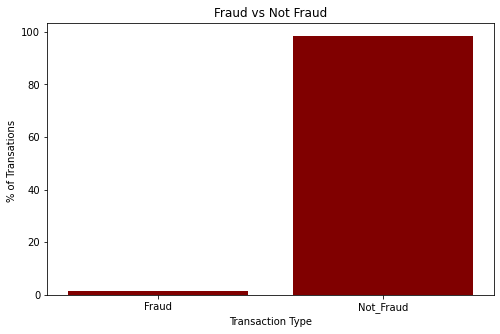

In [9]:
# Shown in graph
data = {'Fraud':fraud, 'Not_Fraud':not_fraud}
YesNo = list(data.keys())
values = list(data.values())
  
fig = plt.figure(figsize = (8, 5))
 
# creating the bar plot
plt.bar(YesNo, values, color ='maroon',
        width = 0.8)
 
plt.xlabel("Transaction Type")
plt.ylabel("% of Transations ")
plt.title("Fraud vs Not Fraud")
plt.show()

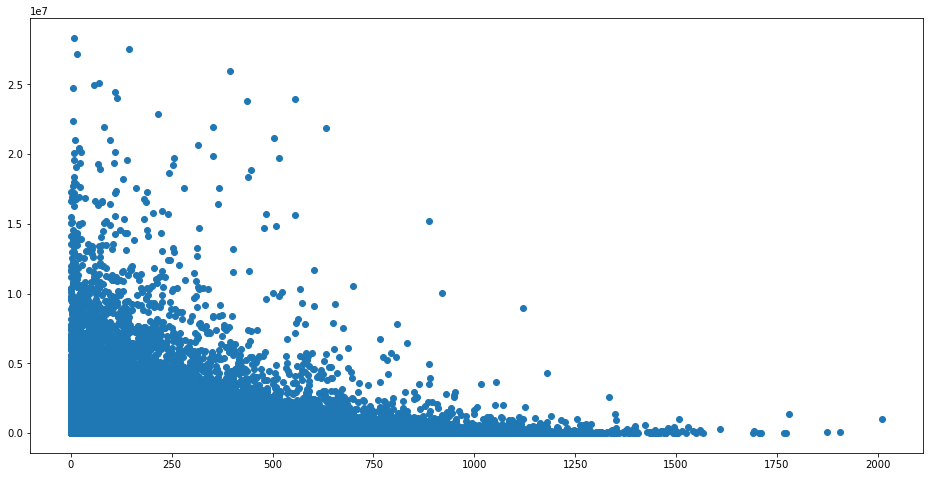

In [10]:
#x= data_preprocessed['transactionAmount']
#y= data_preprocessed['Time']
#plt.scatter(x,y)
#plt.title('Amount vs Time')
fig,ax= plt.subplots(figsize=(16,8))
ax.scatter(data_preprocessed['transactionAmount'],data_preprocessed['time_diff_sec'])
plt.show()

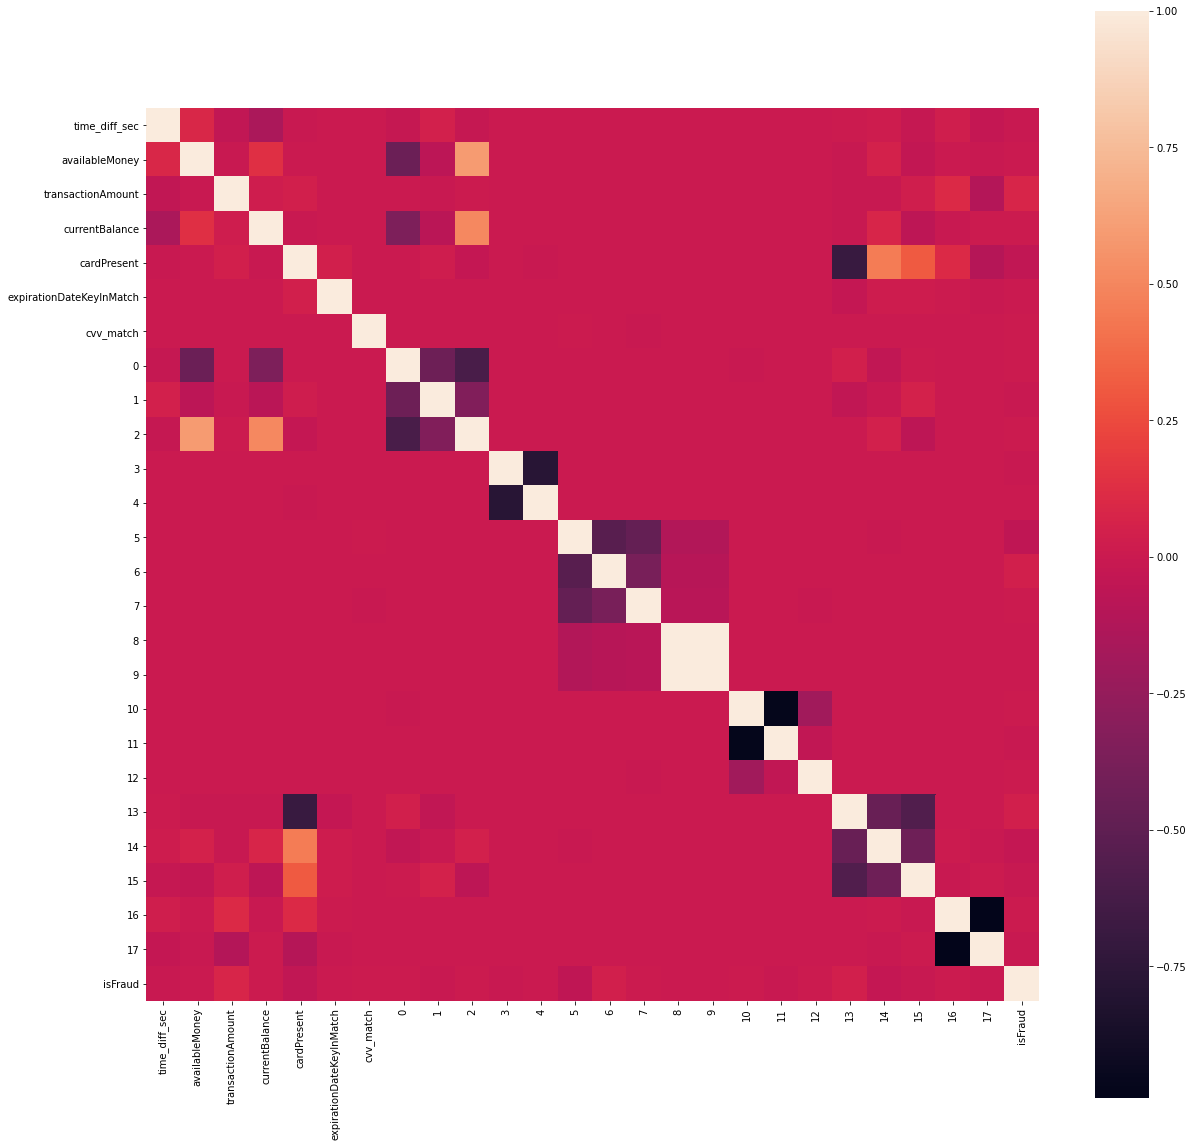

In [11]:
#Correlation matrix
import seaborn as sns 
corr_matrix =data_preprocessed.corr()
fig=plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix,square= True)
plt.show()

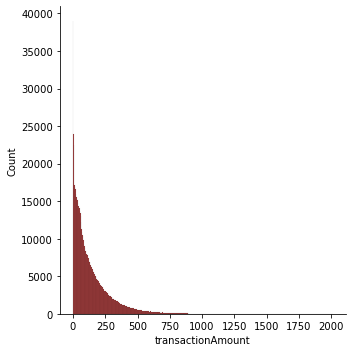

In [12]:
import seaborn as sns

sns.displot(data_preprocessed['transactionAmount'],color='maroon')

## Select the inputs for the Regression
That is to not take the 'isFraud' column

In [13]:
data_preprocessed.shape

(781363, 26)

In [14]:
unscaled_inputs = data_preprocessed.iloc[:,:-1]

In [15]:
unscaled_inputs.head()

,time_diff_sec,availableMoney,transactionAmount,currentBalance,cardPresent,expirationDateKeyInMatch,cvv_match,0,1,2,...,8,9,10,11,12,13,14,15,16,17
0,5063902.0,5000.0,74.51,0.0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,1,1,0
1,2434365.0,5000.0,7.47,0.0,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,1,0
2,2739371.0,5000.0,7.47,0.0,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,1,0
3,2229581.0,5000.0,30.76,0.0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,1,1,0
4,2759168.0,5000.0,57.28,0.0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,1,1,0


# Standardizing the data with Custom scaler

In [16]:
# standardize the inputs

# standardization is one of the most common preprocessing tools
# since data of different magnitude (scale) can be biased towards high values,
# we want all inputs to be of similar magnitude
# this is a peculiarity of machine learning in general - most (but not all) algorithms do badly with unscaled data

# a very useful module we can use is StandardScaler 
# it has much more capabilities than the straightforward 'preprocessing' method
#from sklearn.preprocessing import StandardScaler


# we will create a variable that will contain the scaling information for this particular dataset
# here's the full documentation: http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

# define scaler as an object
#Fraud_scaler = StandardScaler()

In [17]:
# import the libraries needed to create the Custom Scaler
# note that all of them are a part of the sklearn package
# moreover, one of them is actually the StandardScaler module, 
# so you can imagine that the Custom Scaler is build on it

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler

# create the Custom Scaler class

class CustomScaler(BaseEstimator,TransformerMixin): 
    
    # init or what information we need to declare a CustomScaler object
    # and what is calculated/declared as we do
    
    def __init__(self,columns, copy=True, with_mean=True, with_std=True):
        
        # scaler is nothing but a Standard Scaler object
        self.scaler = StandardScaler(copy, with_mean, with_std)
        # with some columns 'twist'
        self.columns = columns
        self.mean_ = None
        self.var_ = None
        
    
    # the fit method, which, again based on StandardScale
    
    def fit(self, X, y=None):
        self.scaler.fit(X[self.columns], y)
        self.mean_ = np.mean(X[self.columns])
        self.var_ = np.var(X[self.columns])
        return self
    
    # the transform method which does the actual scaling

    def transform(self, X, y=None, copy=None):
        
        # record the initial order of the columns
        init_col_order = X.columns
        
        # scale all features that you chose when creating the instance of the class
        X_scaled = pd.DataFrame(self.scaler.transform(X[self.columns]), columns=self.columns)
        
        # declare a variable containing all information that was not scaled
        X_not_scaled = X.loc[:,~X.columns.isin(self.columns)]
        
        # return a data frame which contains all scaled features and all 'not scaled' features
        # use the original order (that you recorded in the beginning)
        return pd.concat([X_not_scaled, X_scaled], axis=1)[init_col_order]

In [18]:
unscaled_inputs.columns.values

array(['time_diff_sec', 'availableMoney', 'transactionAmount',
       'currentBalance', 'cardPresent', 'expirationDateKeyInMatch',
       'cvv_match', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       '10', '11', '12', '13', '14', '15', '16', '17'], dtype=object)

In [19]:
columns_to_not_scale = ['cardPresent','expirationDateKeyInMatch',
       'cvv_match', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       '10', '11', '12', '13', '14', '15', '16', '17']

In [20]:
columns_to_scale = [x for x in unscaled_inputs.columns.values if x not in columns_to_not_scale]

In [21]:
Fraud_scaler = CustomScaler(columns_to_scale)

C:\Users\91987\anaconda3\lib\site-packages\sklearn\utils\validation.py:70: FutureWarning: Pass copy=True, with_mean=True, with_std=True as keyword args. From version 1.0 (renaming of 0.25) passing these as positional arguments will result in an error
  warnings.warn(f"Pass {args_msg} as keyword args. From version "


In [22]:
Fraud_scaler.fit(unscaled_inputs)

AttributeError: 'CustomScaler' object has no attribute 'copy'

AttributeError: 'CustomScaler' object has no attribute 'copy'

In [23]:
scaled_inputs= Fraud_scaler.transform(unscaled_inputs)

In [24]:
scaled_inputs

,time_diff_sec,availableMoney,transactionAmount,currentBalance,cardPresent,expirationDateKeyInMatch,cvv_match,0,1,2,...,8,9,10,11,12,13,14,15,16,17
0,9.111033,-0.138326,-0.423093,-0.701550,1,0,0,1,0,0,...,0,0,1,0,0,0,0,1,1,0
1,4.202272,-0.138326,-0.876873,-0.701550,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,1,0
2,4.771650,-0.138326,-0.876873,-0.701550,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,1,0
3,3.819985,-0.138326,-0.719228,-0.701550,1,0,0,1,0,0,...,0,0,1,0,0,0,0,1,1,0
4,4.808607,-0.138326,-0.539719,-0.701550,1,0,0,1,0,0,...,0,0,1,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781358,-0.266339,4.816239,-0.115721,-0.532247,0,0,0,0,0,1,...,0,0,1,0,0,0,0,1,1,0
781359,0.125634,4.802706,-0.799573,-0.513707,0,0,0,0,0,1,...,0,0,1,0,0,1,0,0,1,0
781360,-0.023395,4.800575,-0.592854,-0.510786,0,0,0,0,0,1,...,0,0,1,0,0,0,0,1,1,0
781361,-0.122108,4.794996,-0.589741,-0.503144,0,0,0,0,0,1,...,0,0,0,0,1,1,0,0,1,0


## split the data into train & test and shuffle

In [25]:
# Importing the relevant module
from sklearn.model_selection import train_test_split

### Split

In [26]:
train_test_split(scaled_inputs,target,train_size=0.8,random_state=20)

[        time_diff_sec  availableMoney  transactionAmount  currentBalance  \
 765379      -0.115948       -0.619507          -0.510884       -0.660735   
 506636      -0.304651       -0.653644          -0.770738       -0.691268   
 163123      -0.140240       -0.300132          -0.280609        1.839262   
 271646      -0.327245       -0.456354           0.615647        0.120690   
 275699       0.167763       -0.595009           0.303335       -0.694299   
 ...               ...             ...                ...             ...   
 702857      -0.264747       -0.651879          -0.927436        0.388573   
 556250      -0.186225       -0.681006          -0.739602       -0.692432   
 744348      -0.277420       -0.620582          -0.927436       -0.659261   
 285919      -0.330627       -0.190788          -0.101507       -0.629674   
 37135       -0.339345       -0.330836          -0.622569        1.108286   
 
         cardPresent  expirationDateKeyInMatch  cvv_match  0  1  2  ...  8

In [27]:
x_train,x_test,y_train,y_test =train_test_split(scaled_inputs,target,train_size=0.8,random_state=20)

In [28]:
print(x_train.shape,y_train.shape)

(625090, 25) (625090,)


In [29]:
print(x_test.shape,y_test.shape)

(156273, 25) (156273,)


# Logistic Regression with sklearn

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

### Training the model

In [31]:
reg= LogisticRegression()
reg.fit(x_train,y_train)

C:\Users\91987\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [32]:
reg.score(x_train,y_train)

0.9841718792493881

## The 1st result comes out to be 98.417 %

## Find the intercept and coefficient

In [33]:
reg.intercept_


array([-1.19458017])

In [34]:
reg.coef_

array([[-0.0830677 , -0.00339485,  0.38911493,  0.03585685, -0.46326434,
         0.41273395,  0.61869081,  0.2502475 ,  0.0630122 ,  0.20689584,
        -0.7738752 , -0.53149416, -1.27409908, -0.10637519, -0.43000562,
        -0.32150807, -0.32150807, -1.05160992, -1.30148448, -0.39455098,
        -0.42372829, -0.99816192, -0.74085963, -0.04248035, -0.27867641]])

In [35]:
feature_name = unscaled_inputs.columns.values

In [36]:
summary_table= pd.DataFrame(columns=['Feature Name'],data=feature_name)

In [37]:
summary_table['Coefficient']=np.transpose(reg.coef_)

In [38]:
summary_table

,Feature Name,Coefficient
0,time_diff_sec,-0.083068
1,availableMoney,-0.003395
2,transactionAmount,0.389115
3,currentBalance,0.035857
4,cardPresent,-0.463264
5,expirationDateKeyInMatch,0.412734
6,cvv_match,0.618691
7,0,0.250247
8,1,0.063012
9,2,0.206896


In [39]:
# reg.intercept_[0]

In [40]:
# do a little Python trick to move the intercept to the top of the summary table
# move all indices by 1
summary_table.index = summary_table.index + 1

# add the intercept at index 0
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]

# sort the df by index
summary_table = summary_table.sort_index()
summary_table

,Feature Name,Coefficient
0,Intercept,-1.194580
1,time_diff_sec,-0.083068
2,availableMoney,-0.003395
3,transactionAmount,0.389115
4,currentBalance,0.035857
5,cardPresent,-0.463264
6,expirationDateKeyInMatch,0.412734
7,cvv_match,0.618691
8,0,0.250247
9,1,0.063012


In [41]:
summary_table['Odds_ratio']= np.exp(summary_table['Coefficient'])   # here , we could also write (summary_table.Coefficient) instead of summary_table['Coefficient'] 

In [42]:
summary_table

,Feature Name,Coefficient,Odds_ratio
0,Intercept,-1.194580,0.302831
1,time_diff_sec,-0.083068,0.920289
2,availableMoney,-0.003395,0.996611
3,transactionAmount,0.389115,1.475674
4,currentBalance,0.035857,1.036507
5,cardPresent,-0.463264,0.629226
6,expirationDateKeyInMatch,0.412734,1.510943
7,cvv_match,0.618691,1.856496
8,0,0.250247,1.284343
9,1,0.063012,1.065040


## Testing the model

In [43]:
# assess the test accuracy of the model
reg.score(x_test,y_test)

0.9843095096401809

In [44]:
# find the predicted probabilities of each class
# the first column shows the probability of a particular observation to be 0, while the second one - to be 1
predicted_proba = reg.predict_proba(x_test)

# let's check that out
predicted_proba

array([[0.99008577, 0.00991423],
       [0.98493399, 0.01506601],
       [0.98983229, 0.01016771],
       ...,
       [0.99457705, 0.00542295],
       [0.98866215, 0.01133785],
       [0.9822705 , 0.0177295 ]])

In [45]:
predicted_proba.shape

(156273, 2)

In [46]:
# select ONLY the probabilities referring to 1s
predicted_proba[:,1]

array([0.00991423, 0.01506601, 0.01016771, ..., 0.00542295, 0.01133785,
       0.0177295 ])

# save the model

In [47]:
# import the relevant module
import pickle

In [48]:
# pickle the model file
with open('model', 'wb') as file:
    pickle.dump(reg, file)

In [50]:
# pickle the scaler file
with open('scaler','wb') as file:
    pickle.dump(Fraud_scaler, file)